In [1]:
import os
import sys

current_directory = os.getcwd()
parent_directory = os.path.dirname(current_directory)
workflow_real_directory = os.path.join(parent_directory, 'workflow_real')
sys.path.append(workflow_real_directory)

import import_ipynb
from load_process_data import load_data, preprocess_data, shuffle_data
from models import BaseGRU, MultiHeadCnnRnn
from keras.regularizers import l2
from model_eval import cross_validate
from visualize import visualize_accuracies


importing Jupyter notebook from load_process_data.ipynb
importing Jupyter notebook from models.ipynb


2024-11-15 10:36:40.579277: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2, in other operations, rebuild TensorFlow with the appropriate compiler flags.


importing Jupyter notebook from model_eval.ipynb
importing Jupyter notebook from visualize.ipynb


In [7]:
# Define hyperparameters

input_shape = (81, 23)  # 81 timesteps with 23 features
num_folds = 5 # Cross-validation
epochs = 30

# GRU hyperparameters

learning_rate = 0.002
dropout = 0.1
recurrent_dropout = 0.1
kernel_regularizer = l2(0.01)  # Regularization strength for kernel
recurrent_regularizer = l2(0.01)  # Regularization strength for recurrent connections

# CNN hyperparameters

kernel_sizes = [8, 5, 3]
filters = [16, 32, 64] 
learning_rate = 0.001
weight_decay = 0.01 

# Create models with regularization

GRUModel = BaseGRU(input_shape=input_shape, 
                learning_rate=learning_rate, 
                dropout=dropout, 
                recurrent_dropout=recurrent_dropout,
                kernel_regularizer=kernel_regularizer, 
                recurrent_regularizer=recurrent_regularizer)

MultiHeadModel = MultiHeadCnnRnn(input_shape=input_shape,
                                 kernel_sizes=kernel_sizes,
                                 filters=filters,
                                 learning_rate=learning_rate,
                                 weight_decay=weight_decay,
                                 dropout=dropout, 
                                 recurrent_dropout=recurrent_dropout,
                                 kernel_regularizer=kernel_regularizer, 
                                 recurrent_regularizer=recurrent_regularizer)
                             
                

Feature amount: 23


In [4]:
# Loading data 

current_directory = os.getcwd()
parent_directory = os.path.dirname(current_directory)
data_path = os.path.join(parent_directory, 'data/')
train_y_list, test_y_list, train_X_list, test_X_list = load_data(data_path)

# Preprocessing data (reshape + standardization)

train_x_list_filtered, test_x_list_filtered = preprocess_data(train_X_list, test_X_list)
print(train_x_list_filtered[0].shape)
print(train_y_list[0].shape)
print(test_x_list_filtered[0].shape)
print(test_y_list[0].shape)


Loading data ...
Data shapes: 
train_x_list: (5,)
training data within each fold: (16063, 81, 25)
train_y_list: (5,)
training label within each fold: (16063,)
Preprocessing data ...
(16063, 81, 23)
(16063,)
(4016, 81, 23)
(4016,)


In [5]:
# Shuffling data
train_x_list_shuffled = []
train_y_list_shuffled = []

for i, fold in enumerate(train_x_list_filtered):
    train_x_fold, train_y_fold = shuffle_data(fold, train_y_list[i])
    train_x_list_shuffled.append(train_x_fold)
    train_y_list_shuffled.append(train_y_fold)


In [27]:
train_x_list_shuffled[0].shape

(16063, 81, 23)

In [10]:
# BaseGRU training and testing

train_accuracies, test_accuracies = cross_validate(GRUModel, num_folds, train_x_list_filtered, 
                                                   train_y_list, test_x_list_filtered, test_y_list)


Testing on Base GRU class: 
Training on fold 1/5
Epoch 1/10
291/502 [================>.............] - ETA: 8s - loss: 0.8876 - accuracy: 0.7059

KeyboardInterrupt: 

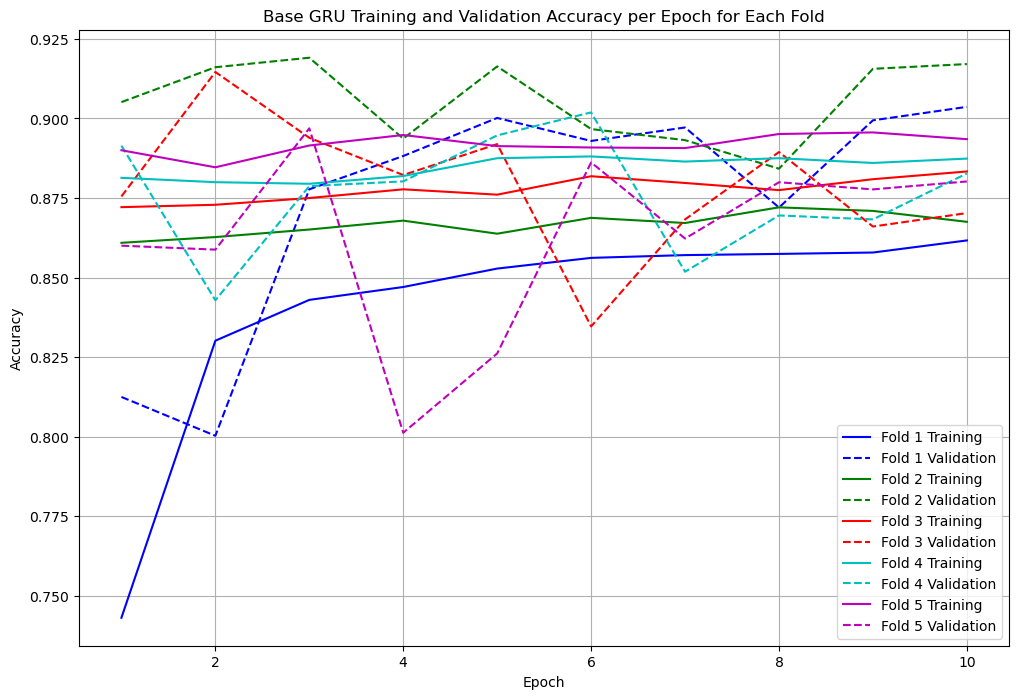

In [8]:
# BaseGRU result visualization

visualize_accuracies(GRUModel, train_accuracies, test_accuracies, epochs)

In [ ]:
# MultiHead training and testing

train_accuracies, test_accuracies = cross_validate(MultiHeadModel, num_folds, train_x_list_shuffled, 
                                                                              train_y_list_shuffled, 
                                                                              test_x_list_filtered, 
                                                                              test_y_list, epochs)

Testing on Multi-head model: 
Training on fold 1/5
Epoch 1/30
126/126 [==============================] - 49s 291ms/step - loss: 6.5744 - accuracy: 0.6562 - val_loss: 2.0159 - val_accuracy: 0.4866
Epoch 2/30
126/126 [==============================] - 69s 551ms/step - loss: 0.9434 - accuracy: 0.8464 - val_loss: 1.6220 - val_accuracy: 0.4866
Epoch 3/30
126/126 [==============================] - 49s 389ms/step - loss: 0.5339 - accuracy: 0.8895 - val_loss: 1.7366 - val_accuracy: 0.4866
Epoch 4/30
126/126 [==============================] - 37s 292ms/step - loss: 0.4582 - accuracy: 0.9043 - val_loss: 1.8163 - val_accuracy: 0.4866
Epoch 5/30
126/126 [==============================] - 36s 290ms/step - loss: 0.4375 - accuracy: 0.9057 - val_loss: 0.4696 - val_accuracy: 0.9089
Epoch 6/30
126/126 [==============================] - 72s 572ms/step - loss: 0.4283 - accuracy: 0.9067 - val_loss: 0.4285 - val_accuracy: 0.9049
Epoch 7/30
126/126 [==============================] - 37s 297ms/step - loss: 0.

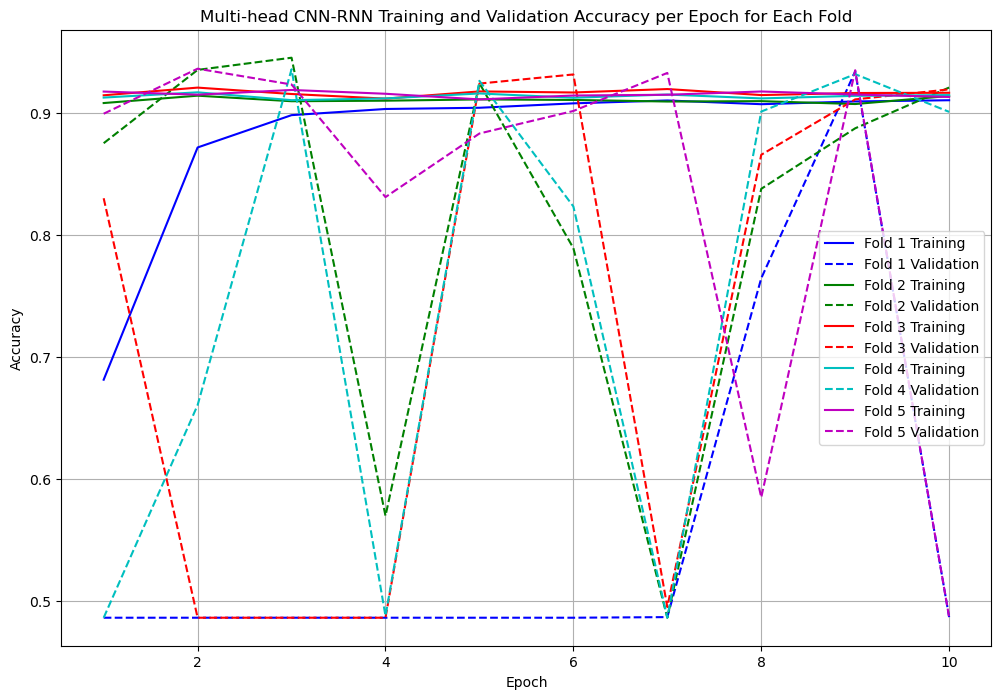

In [10]:
# MultiHead result visualization

visualize_accuracies(MultiHeadModel, train_accuracies, test_accuracies, epochs)

In [14]:
# Define save file paths

save_directory = os.path.join(os.path.dirname(parent_directory), 'saved_models')
gru_model_path = os.path.join(save_directory, 'GRUModel.h5')
multi_head_model_path = os.path.join(save_directory, 'MultiHeadModel.h5')

# Save the models
GRUModel.save(gru_model_path) # Optimized Base GRU Model
MultiHeadModel.save(multi_head_model_path) # Need to fine-tune multihead parameters
